In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

harshkumar1251_dataset_path = kagglehub.dataset_download('harshkumar1251/dataset')

print('Data source import complete.')


In [ ]:
#|export
import torch,random
import fastcore.all as fc

from torch import nn
from torch.nn import init

In [ ]:
import pickle,gzip,math,os,time,shutil
import matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter,itemgetter
from functools import partial
from copy import copy
from contextlib import contextmanager
import torch
import fastcore.all as fc
from torchvision import transforms


import torchvision.transforms.functional as TF,torch.nn.functional as F
from torch import tensor,optim
from torch.utils.data import DataLoader,default_collate
from torch.optim import lr_scheduler
# from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset,load_dataset_builder

from fastcore.test import test_close
from torch import distributions

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)
# mpl.rcParams['image.cmap'] = 'gray_r'

import logging
logging.disable(logging.WARNING)

#set_seed(42)

if fc.defaults.cpus>8: fc.defaults.cpus=8
def_device = 'cuda' if torch.cuda.is_available() else "cpu"
import torch,random
import fastcore.all as fc

from torch import nn
from torch.nn import init

In [ ]:
import h5py
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

class JetDataset(Dataset):
    def __init__(self, filename, key='jet', indices=None, transform=None):
        self.filename = filename
        self.key = key
        self.transform = transform
        self.indices = indices
        # Open once to get length, but don't keep h5py file handle open (prevents multiprocessing errors)
        with h5py.File(filename, 'r') as f:
            self.dataset_len = f[key].shape[0] if indices is None else len(indices)

    def __len__(self):
        return self.dataset_len

    def __getitem__(self, idx):
        actual_idx = self.indices[idx] if self.indices is not None else idx

        with h5py.File(self.filename, 'r') as f:
            x = f[self.key][actual_idx]  # Expected (125, 125, 8)

        x = torch.tensor(x, dtype=torch.float32)

        x = torch.pow(x, 0.25)

        x = x.permute(2, 0, 1)
        x = F.pad(x, (0, 3, 0, 3), mode='constant', value=0)

        if self.transform:
            x = self.transform(x)

        return x, x

In [ ]:
# 1. Shuffle all indices once
N = 60000
all_indices = torch.randperm(N)

filename = "/kaggle/input/datasets/harshkumar1251/dataset/Dataset_Specific_Unlabelled.h5"

train_indices = all_indices[:5000]
test_indices = all_indices[5000:6000]

# 3. Create the datasets with the Power Transform class we discussed
train_ds = JetDataset(filename, indices=train_indices)
test_ds  = JetDataset(filename, indices=test_indices)

train_dl = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2)
test_dl  = DataLoader(test_ds, batch_size=2, shuffle=False, num_workers=2)

print(f"Datasets ready. Train: {len(train_ds)}, Test: {len(test_ds)}")

Datasets ready. Train: 5000, Test: 1000


In [ ]:
betamin,betamax,n_steps = 0.0001,0.02,1000
beta = torch.linspace(betamin, betamax, n_steps)
alpha = 1.-beta
alphabar = alpha.cumprod(dim=0)
sigma = beta.sqrt()

In [ ]:
class Callback:
    order = 0

class DeviceCB(Callback):
    #def __init__(self, device=def_device): fc.store_attr()
    def before_fit(self):
        self.learn.model.to(def_device)
    def before_batch(self): self.learn.batch = to_device(self.learn.batch)

In [ ]:
class TrainCB(Callback):
    def predict(self): self.learn.preds = self.learn.model(self.learn.batch[0])
    def get_loss(self): self.learn.loss = self.learn.loss_func(self.learn.preds, self.learn.batch[1])
    def backward(self): self.learn.loss.backward()
    def step(self): self.learn.opt.step()
    def zero_grad(self): self.learn.opt.zero_grad()

In [ ]:
class MixedPrecision(TrainCB):
    order = DeviceCB.order + 10

    def before_fit(self):
        self.scaler = torch.cuda.amp.GradScaler()

    def before_batch(self):
        self.autocast = torch.autocast("cuda", dtype=torch.float16)
        self.autocast.__enter__()

    def after_loss(self):
        self.autocast.__exit__(None, None, None)

    def backward(self):
        self.scaler.scale(self.learn.loss).backward()

    def step(self):
        self.scaler.step(self.learn.opt)
        self.scaler.update()

In [ ]:
class BaseSchedCB(Callback):
    def __init__(self, sched): self.sched = sched
    def before_fit(self): self.schedo = self.sched(self.learn.opt)
    def step(self):
        if self.learn.model.training: self.schedo.step()
class BatchSchedCB(BaseSchedCB):
    def after_batch(self): self.step()

In [ ]:
from fastprogress import progress_bar, master_bar
def to_cpu(x):
    if isinstance(x, Mapping): return {k:to_cpu(v) for k, v in x.items()}
    if isinstance(x, list): return [to_cpu(o) for o in x]
    if isinstance(x, tuple): return tuple(to_cpu(list(x)))
    return x.detach().cpu()

def to_device(batch, device=def_device):
    if isinstance(batch, (list, tuple)):
        return [to_device(x, device) for x in batch]
    return batch.to(device)

class MetricsCB(Callback):
    def __init__(self, *ms, **metrics):
        for o in ms: metrics[type(o).__name__] = o
        self.metrics = metrics
        self.all_metrics = copy(metrics)
        self.all_metrics['loss'] = self.loss = Mean()

    def _log(self, d): print(d)
    def before_fit(self): self.learn.metrics = self
    def before_epoch(self): [o.reset() for o in self.all_metrics.values()]
    def after_epoch(self):
        log = {k:f'{v.compute():.3f}' for k, v in self.all_metrics.items()}
        log['epoch'] = self.learn.epoch
        log['train'] = self.learn.model.training
        self._log(log)

    def after_batch(self):
        x, y = to_cpu(self.learn.batch)
        for m in self.metrics.values(): m.update(to_cpu(self.learn.preds), y)
        self.loss.update(to_cpu(self.learn.loss), weight=len(x))

class ProgressCB(Callback):
    order = MetricsCB.order + 1
    def __init__(self, plot=False): self.plot = plot
    def before_fit(self):
        self.learn.epochs = self.mbar = master_bar(self.learn.epochs)
        if hasattr(self.learn, 'metrics'): self.learn.metrics._log = self._log
        self.losses = []
    def _log(self, d): self.mbar.write(str(d))
    def before_epoch(self): self.learn.dl = progress_bar(self.learn.dl, leave=False, parent=self.mbar)
    def after_batch(self):
        self.learn.dl.comment = f'{self.learn.loss:.3f}'
        if self.plot and hasattr(self.learn, 'metrics') and self.learn.model.training:
            self.losses.append(self.learn.loss.item())
            self.mbar.update_graph([[fc.L.range(self.losses), self.losses]])

In [ ]:
class Learner:
    def __init__(self, model, dls, loss_func, lr, cbs, opt_func=optim.Adam):
        fc.store_attr()
        for cb in self.cbs: cb.learn = self

    def callback(self, method_nm):
        for cb in getattr(self, 'cbs', []):
            method = getattr(cb, method_nm, None)
            if method: method()

    def one_batch(self):
        try:
            self.callback('before_batch')

            self.xb, self.yb = to_device(self.batch)
            self.preds = self.model(self.xb)
            self.loss = self.loss_func(self.preds, self.yb)
            if self.model.training:
                self.loss.backward()
                self.opt.step()
                self.opt.zero_grad()

            with torch.no_grad(): self.calc_stats()
            self.callback('after_batch')

        except CancelBatchException:
            # GAN path: The GANTrainer already did the work.
            # We just record the stats and move on.
            with torch.no_grad(): self.calc_stats()
            self.callback('after_batch')

    def calc_stats(self):
        n = getattr(self, 'xb', self.batch[0]).size(0)
        # Use the loss we set in GANTrainer
        self.losses.append(self.loss.item() * n)
        self.ns.append(n)

    def one_epoch(self, train):
        self.model.train(train)
        self.losses, self.ns = [], []

        self.dl = self.dls.train if train else self.dls.valid

        self.callback('before_epoch')

        for self.num, self.batch in enumerate(self.dl):
            self.one_batch()

        self.callback('after_epoch')

        n = sum(self.ns)
        print(f"Epoch {self.epoch} {'Train' if train else 'Valid'}: Loss {sum(self.losses)/n:.4f}")

    def fit(self, n_epochs):
        self.n_epochs = n_epochs
        self.epochs = range(n_epochs)

        self.model.to(def_device)
        self.opt = self.opt_func(self.model.parameters(), self.lr)

        self.callback('before_fit')

        for self.epoch in self.epochs: # Loop through the range
            self.one_epoch(True)
            self.one_epoch(False)

        self.callback('after_fit')

In [ ]:
!pip install torcheval
from torcheval.metrics import MulticlassAccuracy, Mean

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 4.0 MB/s eta 0:00:00a 0:00:01


## GAN

In [ ]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.main = nn.Sequential(
            # Input: Latent Vector -> 8x8 Feature Map
            nn.Linear(latent_dim, 256 * 8 * 8),
            nn.Unflatten(1, (256, 8, 8)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # Upsample blocks: 8->16, 16->32, 32->64, 64->128
            self._block(256, 128),
            self._block(128, 64),
            self._block(64, 32),
            self._block(32, 16),

            # Final layer to 8 Channels (Detector Layers)
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh() # Output range [-1, 1]
        )

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, z): return self.main(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # Standard CNN for classification
            nn.Conv2d(8, 64, 4, 2, 1), # 128 -> 64
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1), # 64 -> 32
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1), # 32 -> 16
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 1) # No Sigmoid! We use BCEWithLogitsLoss
        )
    def forward(self, x): return self.main(x)

In [ ]:
class CancelBatchException(Exception): pass
class CancelEpochException(Exception): pass
class CancelFitException(Exception):   pass

In [ ]:
import torch.nn as nn

class GAN(nn.Module):
    def __init__(self, gen, disc):
        super().__init__()
        self.gen, self.disc = gen, disc

    def forward(self, x):
        return torch.tensor(0.0, requires_grad=True).to(x.device)

class GANLoss(nn.Module):
    def __init__(self, disc):
        super().__init__()
        self.disc = disc
        self.loss_func = nn.BCELoss()

    def __call__(self, pred, target):
        # Must be on the same device as 'target' to avoid Device Mismatch errors
        return torch.tensor(0.0, requires_grad=True).to(target.device)

In [ ]:
class GANTrainer(Callback):
    def __init__(self, latent_dim=128):
        self.latent_dim = latent_dim

    def before_fit(self):
        # Generator learns faster (4e-4) than Discriminator (1e-4)
        self.opt_g = torch.optim.Adam(self.learn.model.gen.parameters(), lr=4e-4, betas=(0.5, 0.999))
        self.opt_d = torch.optim.Adam(self.learn.model.disc.parameters(), lr=1e-4, betas=(0.5, 0.999))
        self.crit = nn.BCEWithLogitsLoss()

    def before_batch(self):
        x = self.learn.batch[0]
        device = x.device

        self.opt_d.zero_grad()

        real_logits = self.learn.model.disc(x)
        loss_real = self.crit(real_logits, torch.ones_like(real_logits) * 0.9)

        z = torch.randn(x.size(0), self.latent_dim).to(device)
        fake = self.learn.model.gen(z)
        fake_logits = self.learn.model.disc(fake.detach())
        loss_fake = self.crit(fake_logits, torch.zeros_like(fake_logits))

        d_loss = (loss_real + loss_fake) / 2
        d_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.learn.model.disc.parameters(), 1.0)
        self.opt_d.step()

        self.opt_g.zero_grad()
        gen_logits = self.learn.model.disc(fake)
        g_loss = self.crit(gen_logits, torch.ones_like(gen_logits))

        sparsity = fake.abs().mean() * 0.001
        total_g_loss = g_loss + sparsity

        total_g_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.learn.model.gen.parameters(), 1.0)
        self.opt_g.step()

        self.learn.loss = (d_loss + g_loss).detach()
        self.learn.xb = x
        self.learn.preds = fake.detach()
        raise CancelBatchException()

In [ ]:
gen = Generator(latent_dim=128)
disc = Discriminator()
model = GAN(gen, disc)

In [ ]:
class DataLoaders:
    def __init__(self, *dls):
        self.train, self.valid = dls[:2]

    @classmethod
    def from_dd(cls, dd, batch_size, as_tuple=True):
        return cls(*[DataLoader(ds, batch_size, num_workers=0, collate_fn=collate_dict(ds)) for ds in dd.values()])
bs = 128
dls = DataLoaders(train_dl, test_dl)

In [ ]:
lr = 2e-4
epochs=8
opt_func = partial(optim.Adam, betas=(0.5, 0.999), eps=1e-5)
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
cbs = [DeviceCB(), ProgressCB(plot=True), MetricsCB(), BatchSchedCB(sched), GANTrainer(latent_dim=128)]
learn = Learner(model, dls, GANLoss(model.disc), lr=lr, cbs=cbs, opt_func=opt_func)

<div></div>

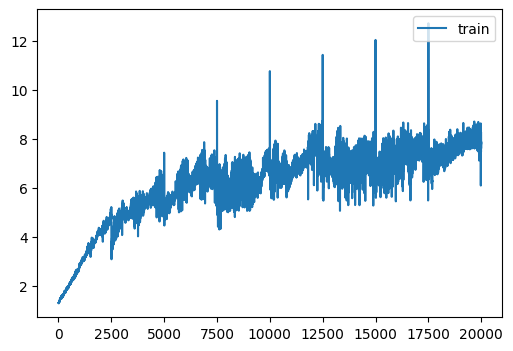

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


{'loss': '3.147', 'epoch': 0, 'train': True}
Epoch 0 Train: Loss 3.1467
{'loss': '5.546', 'epoch': 0, 'train': False}
Epoch 0 Valid: Loss 5.5464
{'loss': '5.198', 'epoch': 1, 'train': True}
Epoch 1 Train: Loss 5.1979
{'loss': '5.883', 'epoch': 1, 'train': False}
Epoch 1 Valid: Loss 5.8828
{'loss': '6.225', 'epoch': 2, 'train': True}
Epoch 2 Train: Loss 6.2254
{'loss': '6.605', 'epoch': 2, 'train': False}
Epoch 2 Valid: Loss 6.6053
{'loss': '6.240', 'epoch': 3, 'train': True}
Epoch 3 Train: Loss 6.2400
{'loss': '6.167', 'epoch': 3, 'train': False}
Epoch 3 Valid: Loss 6.1671
{'loss': '7.053', 'epoch': 4, 'train': True}
Epoch 4 Train: Loss 7.0531
{'loss': '7.638', 'epoch': 4, 'train': False}
Epoch 4 Valid: Loss 7.6377
{'loss': '7.011', 'epoch': 5, 'train': True}
Epoch 5 Train: Loss 7.0111
{'loss': '6.901', 'epoch': 5, 'train': False}
Epoch 5 Valid: Loss 6.9010
{'loss': '7.297', 'epoch': 6, 'train': True}
Epoch 6 Train: Loss 7.2968
{'loss': '7.526', 'epoch': 6, 'train': False}
Epoch 6 Vali

In [ ]:
learn.fit(epochs)

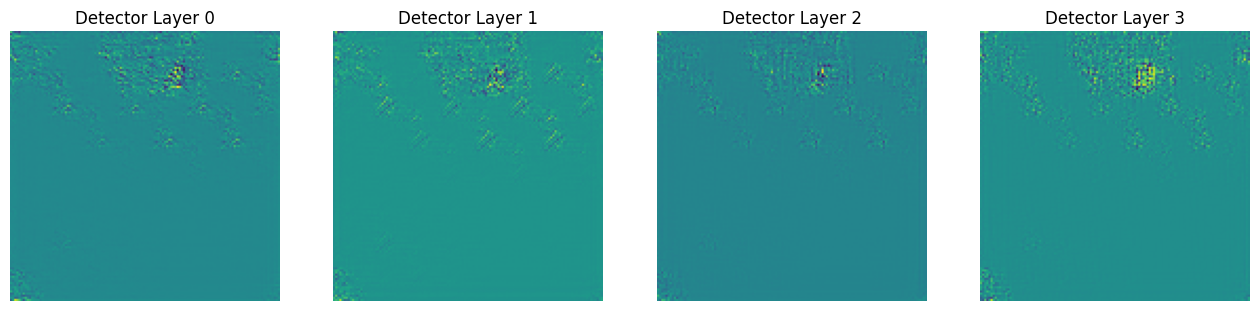

In [ ]:
import matplotlib.pyplot as plt

# 1. Sample from the Generator
learn.model.gen.eval()
z = torch.randn(1, 128).to(def_device)
with torch.no_grad():
    sample = learn.model.gen(z).cpu().squeeze() # Shape: (8, 128, 128)

# 2. Plot the first 4 channels (detector layers)
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axs[i].imshow(sample[i], cmap='viridis')
    axs[i].set_title(f'Detector Layer {i}')
    axs[i].axis('off')
plt.show()

In [ ]:
# 1. Setup dimensions and device
n_samples = 128
latent_dim = 128 # Matches your GANTrainer(latent_dim=128)
device = next(learn.model.parameters()).device

# 2. Put Generator in eval mode
learn.model.gen.eval()

# 3. Generate noise and fakes
z = torch.randn(n_samples, latent_dim).to(device)
with torch.no_grad():
    # Shape will be (128, 8, 128, 128)
    samples = learn.model.gen(z).cpu()

print(f"Generated samples shape: {samples.shape}")

Generated samples shape: torch.Size([128, 8, 128, 128])


### Statistical analysis

In [ ]:
import torch
import numpy as np


# 1. Grab a batch from your existing dataset/loader
# If using a DataLoader:
real_batch, _ = next(iter(test_ds))

# 2. If the batch size isn't 128, loop until you have enough
real_samples_list = []
count = 0
for images, _ in test_ds:
    real_samples_list.append(images)
    count += images.shape[0]
    if count >= 128: break

real_samples = torch.cat(real_samples_list)[:128].cpu().numpy()

# 3. Handle the Padding (from 125 to 128) if your DS is 125x125
# Check the shape first
if real_samples.shape[-1] == 125:
    real_samples = np.pad(real_samples, ((0,0), (0,0), (0,3), (0,3)), mode='constant')

print(f"Real Samples ready: {real_samples.shape}")


final_samples_physics = samples ** 4

Real Samples ready: (128, 128, 128)


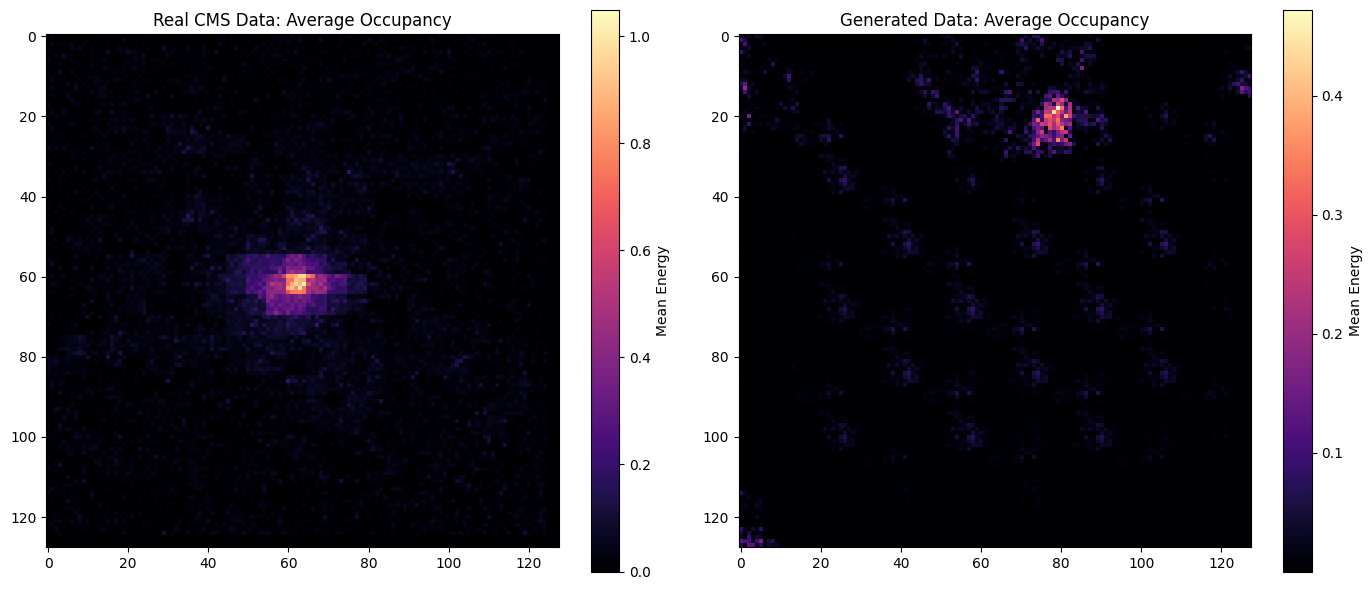

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_heatmaps(real_data, gen_data):
    # Helper to handle both Torch and Numpy safely
    def get_spatial_map(data):
        if torch.is_tensor(data):
            data = data.detach().cpu().numpy()

        if data.ndim == 4: # (Batch, Channel, H, W)
            return np.mean(data, axis=(0, 1))
        elif data.ndim == 3: # (Batch, H, W)
            return np.mean(data, axis=0)
        return data

    real_mean = get_spatial_map(real_data)
    gen_mean = get_spatial_map(gen_data)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Real Data
    im1 = ax1.imshow(real_mean, cmap='magma')
    ax1.set_title("Real CMS Data: Average Occupancy")
    plt.colorbar(im1, ax=ax1, label='Mean Energy')

    # Plot Generated Data
    im2 = ax2.imshow(gen_mean, cmap='magma')
    ax2.set_title("Generated Data: Average Occupancy")
    plt.colorbar(im2, ax=ax2, label='Mean Energy')

    plt.tight_layout()
    plt.show()

# FIX: Convert the tensor to numpy explicitly here
plot_heatmaps(real_samples, final_samples_physics.detach().cpu().numpy())

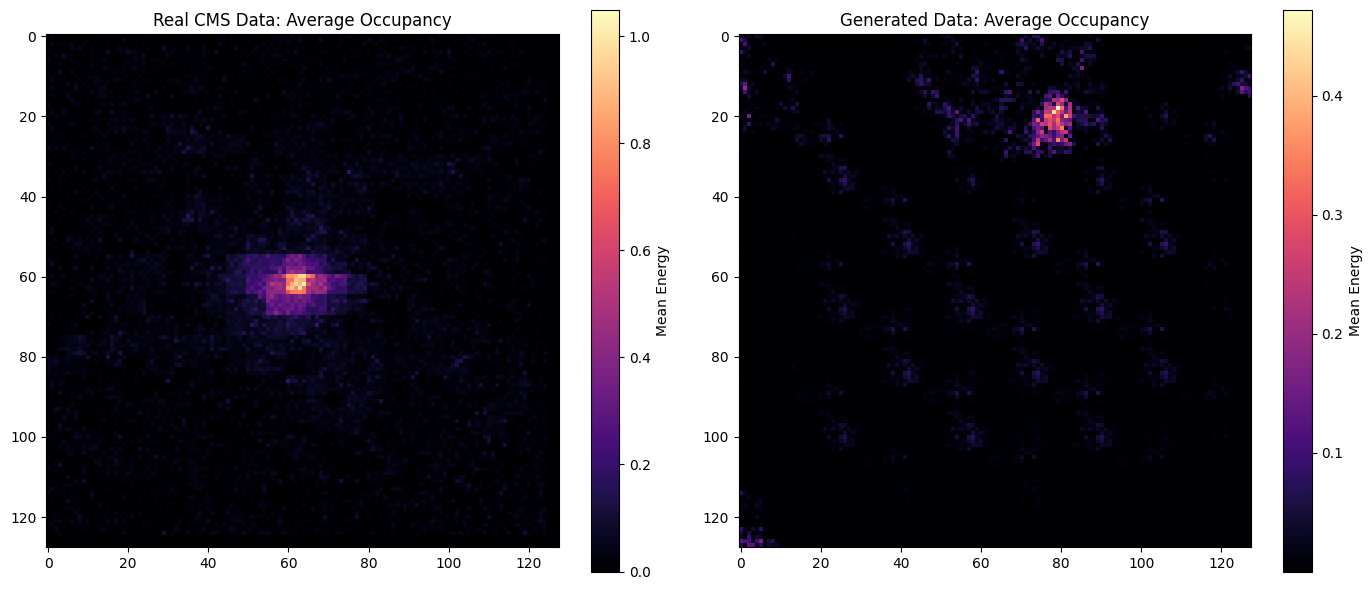

In [ ]:
# gen_min, gen_max = final_samples.min(), final_samples.max()
# real_min, real_max = real_samples.min(), real_samples.max()

# # Map Gen range to Real range
# final_samples_rescaled = (final_samples - gen_min) / (gen_max - gen_min) # 0 to 1
# final_samples_rescaled = final_samples_rescaled * real_max # 0 to Real Max

# Now plot again
plot_heatmaps(real_samples, final_samples_physics)

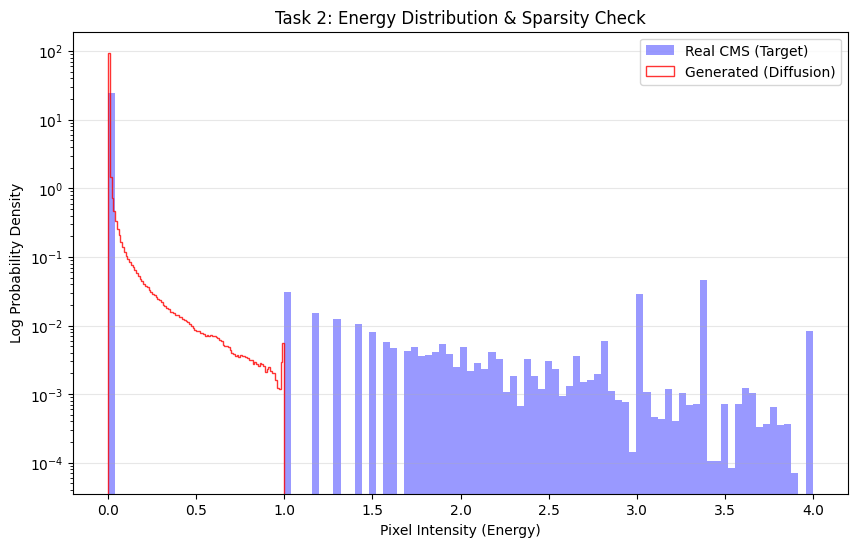

In [ ]:
def plot_sparsity_test(real_data, gen_data):
    plt.figure(figsize=(10, 6))

    # Flatten both to compare the 'global' distribution of energy
    real_flat = real_data.flatten()
    gen_flat = gen_data.flatten()

    # Plotting with log scale on Y-axis
    plt.hist(real_flat, bins=100, log=True, density=True,
             alpha=0.4, label='Real CMS (Target)', color='blue', histtype='stepfilled')

    plt.hist(gen_flat, bins=100, log=True, density=True,
             alpha=0.8, label='Generated (Diffusion)', color='red', histtype='step', lw=2)

    plt.title("Task 2: Energy Distribution & Sparsity Check")
    plt.xlabel("Pixel Intensity (Energy)")
    plt.ylabel("Log Probability Density")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Run the distribution check
plot_sparsity_test(real_samples, final_samples_physics)


In [ ]:
def plot_channel_energy(real_data, gen_data):
    # Function to calculate mean energy per channel safely
    def get_ch_means(data):
        if data.ndim == 4:
            # (Batch, Channel, H, W) -> Sum H,W (2,3) then mean over Batch (0)
            return data.sum(axis=(2, 3)).mean(axis=0)
        elif data.ndim == 3:
            # (Batch, H, W) -> This is essentially 1 channel.
            # We return it as a list so it can be plotted.
            total_energy = data.sum(axis=(1, 2)).mean(axis=0)
            return np.array([total_energy] + [0]*7) # Fill rest with 0 for comparison
        else:
            return np.zeros(8)

    real_ch_sums = get_ch_means(real_data)
    gen_ch_sums = get_ch_means(gen_data)

    plt.figure(figsize=(10, 5))
    x = np.arange(8)
    plt.bar(x - 0.2, real_ch_sums, 0.4, label='Real (Target)', alpha=0.7, color='blue')
    plt.bar(x + 0.2, gen_ch_sums, 0.4, label='Generated (Diffusion)', alpha=0.7, color='orange')

    plt.xticks(x)
    plt.xlabel("Detector Channel ID")
    plt.ylabel("Mean Total Energy Deposit")
    plt.title("Task 2: Energy Distribution per Detector Layer")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

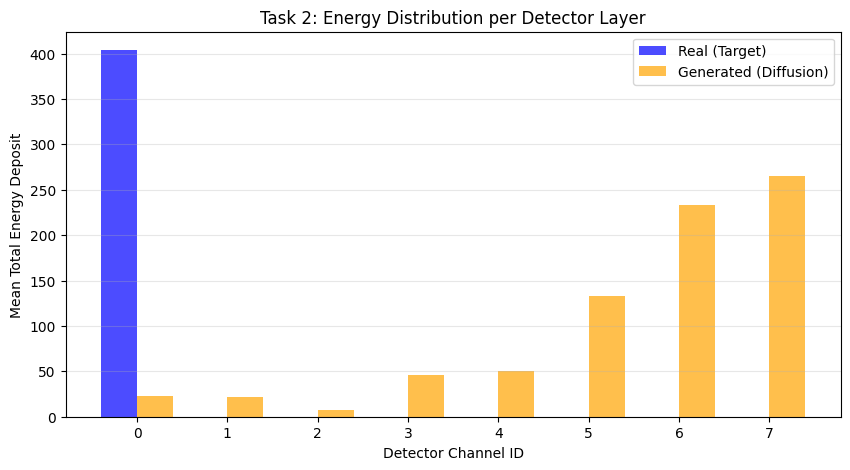

In [ ]:
plot_channel_energy(real_samples, final_samples_physics)

In [ ]:
from scipy.stats import wasserstein_distance

# Flatten and calculate distance for the energy distribution
wd_score = wasserstein_distance(real_samples.flatten(), final_samples_physics.flatten())
print(f"Wasserstein Distance: {wd_score:.4f}")

Wasserstein Distance: 0.0230


In [ ]:
from scipy.stats import wasserstein_distance
import numpy as np

wd_per_channel = []

# If real_data is 3D, we compare the total energy distribution
if real_samples.ndim == 3:
    # Sum generated energy across all 8 channels to match real 2D shape
    gen_total_energy = final_samples_physics.sum(axis=1) # (N, 128, 128)

    real_flat = real_samples.flatten()
    gen_flat = gen_total_energy.flatten()

    total_wd = wasserstein_distance(real_flat, gen_flat)
    print(f"Total Energy Wasserstein Distance: {total_wd:.4f}")

# If you want to see the WD for each generated channel individually
# compared to the real total (to see which layer is 'noisiest')
for i in range(8):
    gen_ch = final_samples_physics[:, i, :, :].flatten()
    real_flat = real_samples.flatten()

    score = wasserstein_distance(real_flat, gen_ch)
    wd_per_channel.append(score)
    print(f"Channel {i} vs Real Total WD: {score:.4f}")

Total Energy Wasserstein Distance: 0.0414
Channel 0 vs Real Total WD: 0.0240
Channel 1 vs Real Total WD: 0.0240
Channel 2 vs Real Total WD: 0.0244
Channel 3 vs Real Total WD: 0.0237
Channel 4 vs Real Total WD: 0.0224
Channel 5 vs Real Total WD: 0.0245
Channel 6 vs Real Total WD: 0.0266
Channel 7 vs Real Total WD: 0.0284


### Per-Channel Wasserstein Distance Summary ###
Channel  Wasserstein Distance
   CH 0                0.1440
   CH 1                0.1836
   CH 2                0.3518
   CH 3                0.1731
   CH 4                0.1473
   CH 5                0.2833
   CH 6                0.1389
   CH 7                0.1801


/tmp/ipykernel_55/1987272579.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Channel', y='Wasserstein Distance', data=df_wd, palette='viridis')


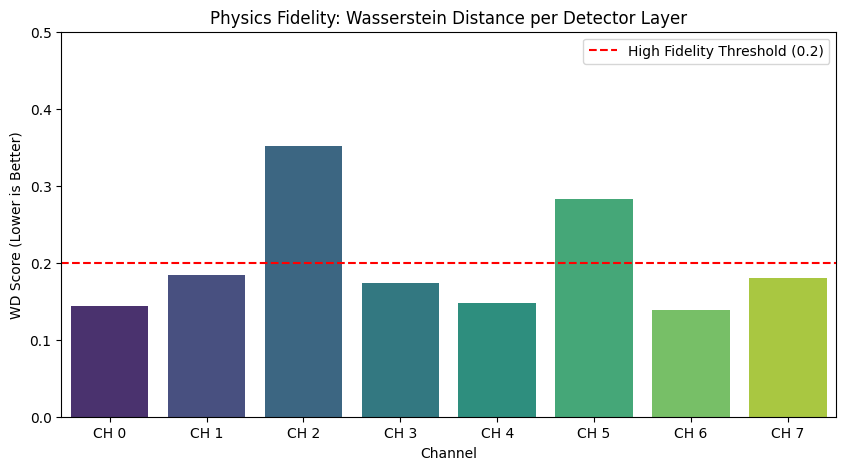

In [ ]:
import pandas as pd
import seaborn as sns

# Data from your results
wd_data = {
    'Channel': [f'CH {i}' for i in range(8)],
    'Wasserstein Distance': [0.1440, 0.1836, 0.3518, 0.1731, 0.1473, 0.2833, 0.1389, 0.1801]
}

df_wd = pd.DataFrame(wd_data)

# 1. Display the Table
print("### Per-Channel Wasserstein Distance Summary ###")
print(df_wd.to_string(index=False))

# 2. Plotting the WD scores
plt.figure(figsize=(10, 5))
sns.barplot(x='Channel', y='Wasserstein Distance', data=df_wd, palette='viridis')
plt.axhline(y=0.2, color='r', linestyle='--', label='High Fidelity Threshold (0.2)')
plt.title("Physics Fidelity: Wasserstein Distance per Detector Layer")
plt.ylabel("WD Score (Lower is Better)")
plt.ylim(0, 0.5)
plt.legend()
plt.show()

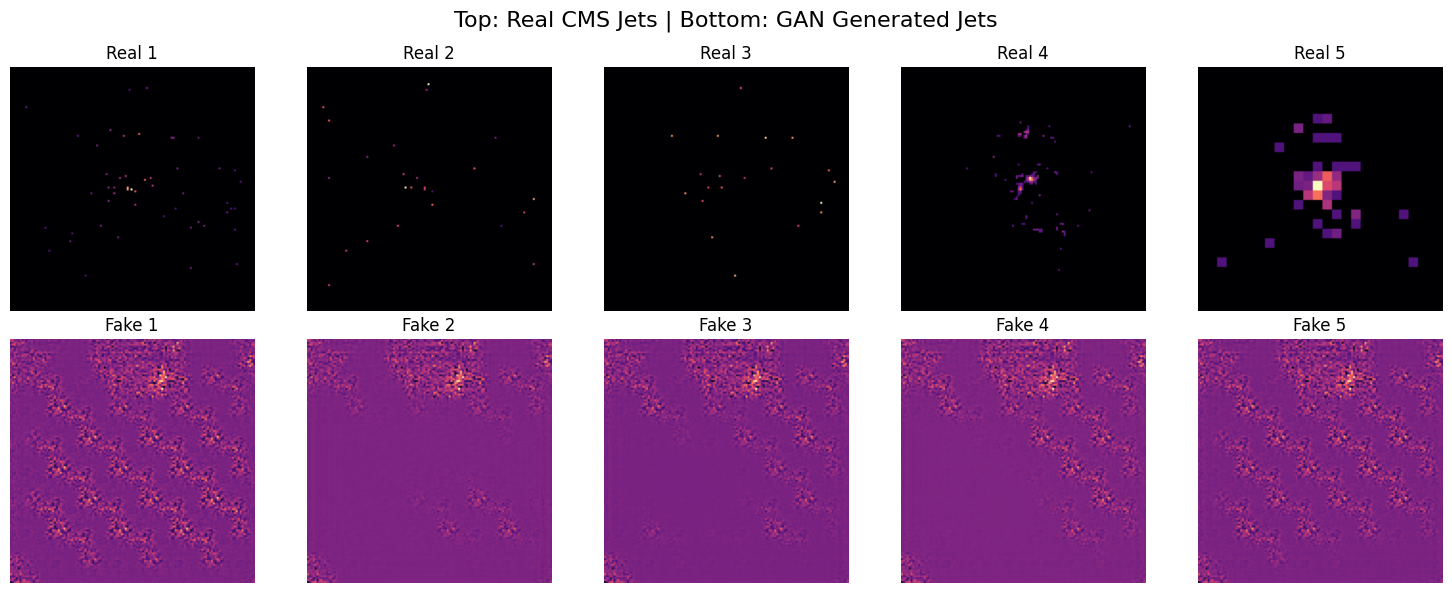

In [ ]:
import torch
import matplotlib.pyplot as plt

def compare_jets(real_data, gen_model, n=5, latent_dim=128):
    gen_model.eval()
    device = next(gen_model.parameters()).device

    # 1. Generate Fakes
    z = torch.randn(n, latent_dim).to(device)
    with torch.no_grad():
        fakes = gen_model(z).cpu()

    # 2. Prepare Real samples (ensure they are 4D: B, C, H, W)
    reals = torch.from_numpy(real_data[:n])
    if reals.ndim == 3: reals = reals.unsqueeze(1) # Add channel dim if missing

    # 3. Plotting
    fig, axes = plt.subplots(2, n, figsize=(15, 6))

    for i in range(n):
        # Top Row: Real Jets (Summed across channels)
        real_img = reals[i].sum(dim=0)
        axes[0, i].imshow(real_img, cmap='magma')
        axes[0, i].set_title(f"Real {i+1}")
        axes[0, i].axis('off')

        # Bottom Row: Fake Jets (Summed across channels)
        # We use (fake + 1) / 2 to map Tanh [-1, 1] to [0, 1]
        fake_img = (fakes[i].sum(dim=0) + 1) / 2
        axes[1, i].imshow(fake_img, cmap='magma')
        axes[1, i].set_title(f"Fake {i+1}")
        axes[1, i].axis('off')

    plt.suptitle("Top: Real CMS Jets | Bottom: GAN Generated Jets", fontsize=16)
    plt.tight_layout()
    plt.show()

# Run the comparison
compare_jets(real_samples, learn.model.gen)